# 1.네이버 API


## 1.1.통합검색어 트렌드 API
- 서비스 : https://datalab.naver.com/keyword/trendSearch.naver
- 내 애플리케이션 > dss 애플리케이션 > API 설정 > 데이터랩(검색어 트렌드) 추가
- 사용법 : https://developers.naver.com/docs/serviceapi/datalab/search/search.md#통합-검색어-트렌드

In [ ]:
# %pip install requests

In [8]:
import requests
import matplotlib.pylab as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [14]:

# Client_ID, Client_Scret =

from dotenv import load_dotenv
import os
import json

load_dotenv()

Client_ID = os.getenv("naver_client_id_1")
Client_Secret = os.getenv("naver_secret_key_1")

print(Client_ID)

print(Client_Secret)


EAx_c1aQYNooCqwXJgAL
4Z4FHZI7xo


**1) URL**

In [15]:
url = 'https://openapi.naver.com/v1/datalab/search'     # 네이버 데어터랩 API 엔드포인트 URL. 이 URL로 요청을 보내서 데이터를 가져옴.

**2) request > response**

In [17]:
params = {
    "startDate": "2020-01-01",
    "endDate": "2026-04-01",
    "timeUnit": "month",
    "keywordGroups": [
        {"groupName": "전기차", "keywords": ["충전", "충전소", "충전기"]},
        {"groupName": "전기차 충전기", "keywords": ["고장", "불편"]},
    ]
}

In [18]:

headers = {
    "Content-Type": "application/json",
    "X-Naver-Client-ID" : Client_ID,
    "X-Naver-Client-Secret" : Client_Secret
}

In [19]:
response = requests.post(url, data=json.dumps(params), headers=headers) # 데이터를 보내고 서버에서 처리하기 위해 사용하는 요청 방식
response

<Response [200]>

**3) parsing**

In [20]:
response.json()

{'startDate': '2020-01-01',
 'endDate': '2026-04-16',
 'timeUnit': 'month',
 'results': [{'title': '전기차',
   'keywords': ['충전', '충전소', '충전기'],
   'data': [{'period': '2020-01-01', 'ratio': 28.77892},
    {'period': '2020-02-01', 'ratio': 28.4728},
    {'period': '2020-03-01', 'ratio': 31.40411},
    {'period': '2020-04-01', 'ratio': 31.59516},
    {'period': '2020-05-01', 'ratio': 32.2665},
    {'period': '2020-06-01', 'ratio': 30.78344},
    {'period': '2020-07-01', 'ratio': 31.90867},
    {'period': '2020-08-01', 'ratio': 33.66829},
    {'period': '2020-09-01', 'ratio': 32.11134},
    {'period': '2020-10-01', 'ratio': 33.31257},
    {'period': '2020-11-01', 'ratio': 33.90052},
    {'period': '2020-12-01', 'ratio': 39.04112},
    {'period': '2021-01-01', 'ratio': 35.50076},
    {'period': '2021-02-01', 'ratio': 31.67539},
    {'period': '2021-03-01', 'ratio': 35.10703},
    {'period': '2021-04-01', 'ratio': 32.36889},
    {'period': '2021-05-01', 'ratio': 31.51494},
    {'period': '20

In [21]:
# API 응답 데이터를 JSON 형식으로 변환. 응답 데이터에서 'results'키에 해당하는 값을 가져옴
datas = response.json()['results']

print(datas)

[{'title': '전기차', 'keywords': ['충전', '충전소', '충전기'], 'data': [{'period': '2020-01-01', 'ratio': 28.77892}, {'period': '2020-02-01', 'ratio': 28.4728}, {'period': '2020-03-01', 'ratio': 31.40411}, {'period': '2020-04-01', 'ratio': 31.59516}, {'period': '2020-05-01', 'ratio': 32.2665}, {'period': '2020-06-01', 'ratio': 30.78344}, {'period': '2020-07-01', 'ratio': 31.90867}, {'period': '2020-08-01', 'ratio': 33.66829}, {'period': '2020-09-01', 'ratio': 32.11134}, {'period': '2020-10-01', 'ratio': 33.31257}, {'period': '2020-11-01', 'ratio': 33.90052}, {'period': '2020-12-01', 'ratio': 39.04112}, {'period': '2021-01-01', 'ratio': 35.50076}, {'period': '2021-02-01', 'ratio': 31.67539}, {'period': '2021-03-01', 'ratio': 35.10703}, {'period': '2021-04-01', 'ratio': 32.36889}, {'period': '2021-05-01', 'ratio': 31.51494}, {'period': '2021-06-01', 'ratio': 32.41006}, {'period': '2021-07-01', 'ratio': 34.72491}, {'period': '2021-08-01', 'ratio': 35.0912}, {'period': '2021-09-01', 'ratio': 32.89879

In [22]:
import pandas as pd

dfs = []
for data in datas:                   # 결과 데이터를 반복
    df = pd.DataFrame(data['data'])  # 각 키워드 그룹의 데이터('data')를 DataFrame으로 변환
    df['title'] = data['title']      # 주식, 코인, 부동산
    dfs.append(df)

print(dfs)

[        period     ratio title
0   2020-01-01  28.77892   전기차
1   2020-02-01  28.47280   전기차
2   2020-03-01  31.40411   전기차
3   2020-04-01  31.59516   전기차
4   2020-05-01  32.26650   전기차
..         ...       ...   ...
71  2025-12-01  29.41226   전기차
72  2026-01-01  40.32258   전기차
73  2026-02-01  32.44384   전기차
74  2026-03-01  34.78192   전기차
75  2026-04-01  14.86024   전기차

[76 rows x 3 columns],         period     ratio    title
0   2020-01-01   8.40124  전기차 충전기
1   2020-02-01   7.99590  전기차 충전기
2   2020-03-01  11.48349  전기차 충전기
3   2020-04-01  20.28690  전기차 충전기
4   2020-05-01  11.96482  전기차 충전기
..         ...       ...      ...
71  2025-12-01   4.49459  전기차 충전기
72  2026-01-01   4.46609  전기차 충전기
73  2026-02-01   3.77892  전기차 충전기
74  2026-03-01   4.52098  전기차 충전기
75  2026-04-01   2.28846  전기차 충전기

[76 rows x 3 columns]]


**4) preprocessing**

In [23]:
result_df = pd.concat(dfs, ignore_index=True) # 모든 키워드 그룹 데이터를 하나의 DataFrame으로 병합
result_df.tail()

,period,ratio,title
147,2025-12-01,4.49459,전기차 충전기
148,2026-01-01,4.46609,전기차 충전기
149,2026-02-01,3.77892,전기차 충전기
150,2026-03-01,4.52098,전기차 충전기
151,2026-04-01,2.28846,전기차 충전기


In [24]:
# pivot 생성
pivot_df = result_df.pivot(index='period', columns='title', values='ratio')

pivot_df.head()

title,전기차,전기차 충전기
period,,
2020-01-01,28.77892,8.40124
2020-02-01,28.47280,7.99590
2020-03-01,31.40411,11.48349
2020-04-01,31.59516,20.28690
2020-05-01,32.26650,11.96482


**5) visualization**

In [26]:
%config InlineBackend.figure_formats = {'png', 'retina'}

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/Volumes/Jexists/gitHub/sk_network/04.data_collection/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE J

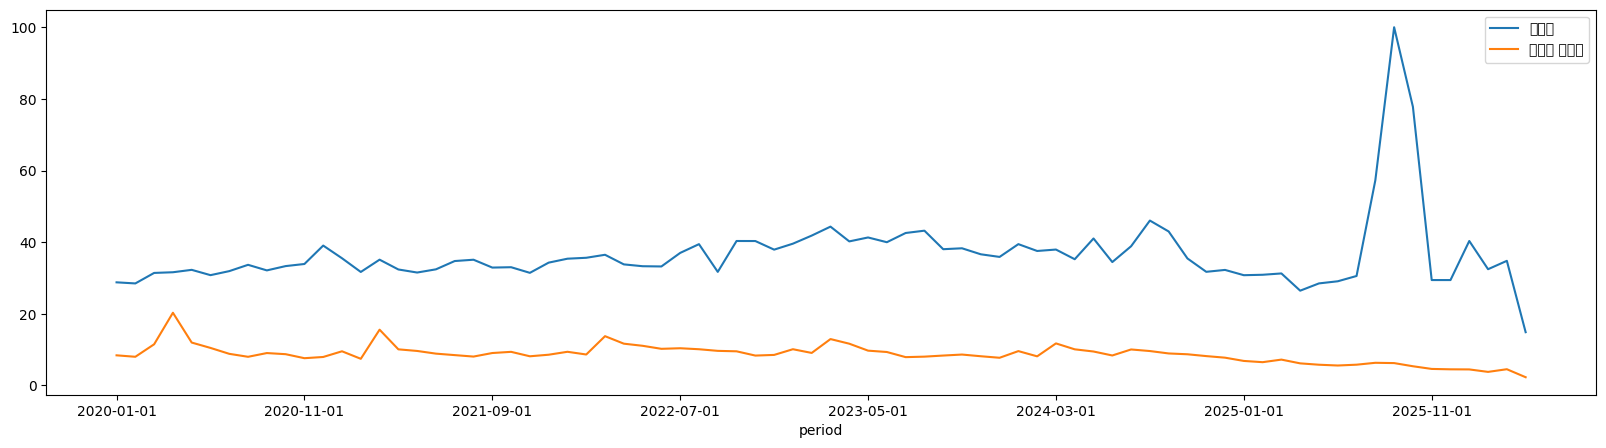

In [25]:
pivot_df.plot(figsize=(20,5))
plt.legend(loc=0)       # loc : 범례 위치
plt.show()

## 1.2. 네이버 검색 API
- 네이버 블로그 검색 API 파이썬 코드
-  https://developers.naver.com/docs/serviceapi/search/blog/blog.md#python

In [22]:

# Client_ID, Client_Scret =

from dotenv import load_dotenv
import os
import json

load_dotenv()

client_id = os.getenv("naver_client_id_2")
client_secret = os.getenv("naver_secret_key_2")



In [26]:
# 네이버 검색 API 예제 - 블로그 검색
import os
import sys
import urllib.request
# client_id = "YOUR_CLIENT_ID"
# client_secret = "YOUR_CLIENT_SECRET"
encText = urllib.parse.quote("봄 꽃 여행지")
url = "https://openapi.naver.com/v1/search/blog?query=" + encText + "&display=100&start=1"# JSON 결과
# url = "https://openapi.naver.com/v1/search/blog.xml?query=" + encText # XML 결과
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id",client_id)
request.add_header("X-Naver-Client-Secret",client_secret)
response = urllib.request.urlopen(request)
rescode = response.getcode()
if(rescode==200):
    response_body = response.read()
    print(response_body.decode('utf-8'))
else:
    print("Error Code:" + rescode)

{
	"lastBuildDate":"Fri, 10 Apr 2026 16:17:21 +0900",
	"total":65579,
	"start":1,
	"display":100,
	"items":[
		{
			"title":"광양 매화축제 실시간 개화 상황 | 3월 <b>봄꽃 여행지<\/b> 추천, 주차... ",
			"link":"https:\/\/blog.naver.com\/ladyndeok\/224218894719",
			"description":"3월 <b>봄꽃 여행지<\/b>로 방문하기에도 좋은 시기라 봄 여행을 계획 중이라면 한 번 방문해보셔도 좋을 것... 데이트 여행지로도 너무 좋은곳이라 3월 <b>봄꽃 여행지<\/b>를 찾고 있다면 지금 시기의 광양 매화축제 방문을... ",
			"bloggername":"계획형 여행 기록",
			"bloggerlink":"blog.naver.com\/ladyndeok",
			"postdate":"20260316"
		},
		{
			"title":"강진 남미륵사 4월 <b>봄꽃 여행지<\/b> 철쭉 겹벚꽃 서부해당화 축제",
			"link":"https:\/\/blog.naver.com\/5004yurim\/224220733570",
			"description":"4월 <b>봄꽃<\/b> 여행 완벽 정보! 200만 그루 서부해당화, 철쭉, 겹벚꽃이 한꺼번에 피어나는 <b>꽃<\/b> 천국. 2026년... 행사 <b>봄꽃<\/b> 프린지 공연 <b>봄<\/b> 소풍 음악회 메이드인 강진 예술제 부대 행사 <b>봄꽃<\/b> 관광사진 공모전 강진愛... ",
			"bloggername":"유림여사 제4의 활동",
			"bloggerlink":"blog.naver.com\/5004yurim",
			"postdate":"20260318"
		},
		{
			"title":"4월 <b>봄꽃 여행지<\/b> 추천, 벚꽃 명소 경기도 곤지암 화담숲 예약... ",
			"link":"https:\/\

**1) JSON 데이터 파싱**
- API 응답 데이터를 JSON 형식으로 변환하여 Python에서 사용할 수 있는 딕셔너리로 만든다.

In [28]:
if(rescode==200):
    # response_body = response.read()
    text_data = response_body.decode('utf-8')
    json_data = json.loads(text_data)
    print(json_data)

{'lastBuildDate': 'Fri, 10 Apr 2026 16:17:21 +0900', 'total': 65579, 'start': 1, 'display': 100, 'items': [{'title': '광양 매화축제 실시간 개화 상황 | 3월 <b>봄꽃 여행지</b> 추천, 주차... ', 'link': 'https://blog.naver.com/ladyndeok/224218894719', 'description': '3월 <b>봄꽃 여행지</b>로 방문하기에도 좋은 시기라 봄 여행을 계획 중이라면 한 번 방문해보셔도 좋을 것... 데이트 여행지로도 너무 좋은곳이라 3월 <b>봄꽃 여행지</b>를 찾고 있다면 지금 시기의 광양 매화축제 방문을... ', 'bloggername': '계획형 여행 기록', 'bloggerlink': 'blog.naver.com/ladyndeok', 'postdate': '20260316'}, {'title': '강진 남미륵사 4월 <b>봄꽃 여행지</b> 철쭉 겹벚꽃 서부해당화 축제', 'link': 'https://blog.naver.com/5004yurim/224220733570', 'description': '4월 <b>봄꽃</b> 여행 완벽 정보! 200만 그루 서부해당화, 철쭉, 겹벚꽃이 한꺼번에 피어나는 <b>꽃</b> 천국. 2026년... 행사 <b>봄꽃</b> 프린지 공연 <b>봄</b> 소풍 음악회 메이드인 강진 예술제 부대 행사 <b>봄꽃</b> 관광사진 공모전 강진愛... ', 'bloggername': '유림여사 제4의 활동', 'bloggerlink': 'blog.naver.com/5004yurim', 'postdate': '20260318'}, {'title': '4월 <b>봄꽃 여행지</b> 추천, 벚꽃 명소 경기도 곤지암 화담숲 예약... ', 'link': 'https://blog.naver.com/cafeinfofam/224239045159', 'description': '아기자기한 봄꽃

**2) 필요한 데이터 추출**
- JSON 데이터를 확인한 후, 원하는 정보(예: 블로그 제목, 링크, 설명 등)를 추출.

In [29]:
json_data['items']

[{'title': '광양 매화축제 실시간 개화 상황 | 3월 <b>봄꽃 여행지</b> 추천, 주차... ',
  'link': 'https://blog.naver.com/ladyndeok/224218894719',
  'description': '3월 <b>봄꽃 여행지</b>로 방문하기에도 좋은 시기라 봄 여행을 계획 중이라면 한 번 방문해보셔도 좋을 것... 데이트 여행지로도 너무 좋은곳이라 3월 <b>봄꽃 여행지</b>를 찾고 있다면 지금 시기의 광양 매화축제 방문을... ',
  'bloggername': '계획형 여행 기록',
  'bloggerlink': 'blog.naver.com/ladyndeok',
  'postdate': '20260316'},
 {'title': '강진 남미륵사 4월 <b>봄꽃 여행지</b> 철쭉 겹벚꽃 서부해당화 축제',
  'link': 'https://blog.naver.com/5004yurim/224220733570',
  'description': '4월 <b>봄꽃</b> 여행 완벽 정보! 200만 그루 서부해당화, 철쭉, 겹벚꽃이 한꺼번에 피어나는 <b>꽃</b> 천국. 2026년... 행사 <b>봄꽃</b> 프린지 공연 <b>봄</b> 소풍 음악회 메이드인 강진 예술제 부대 행사 <b>봄꽃</b> 관광사진 공모전 강진愛... ',
  'bloggername': '유림여사 제4의 활동',
  'bloggerlink': 'blog.naver.com/5004yurim',
  'postdate': '20260318'},
 {'title': '4월 <b>봄꽃 여행지</b> 추천, 벚꽃 명소 경기도 곤지암 화담숲 예약... ',
  'link': 'https://blog.naver.com/cafeinfofam/224239045159',
  'description': '아기자기한 봄꽃들이 곳곳마다 흐드러지게 피었으니 어디론가 떠나고 싶어지는 계절입니다. 저 역시... #4월여행지추천 #<b>봄꽃여행지</b> #벚꽃명소 #경기

**3) 데이터 전처리**
- 정규표현식을 이용하여 데이터를 전처리한다.

In [30]:
import re

# HTML 태그 제거 함수
def remove_html_tags(text):
    if text:
        clean_text = re.sub(r'<.*?>', '', text) # 정규표현식으로 HTML 태그 제거
        return clean_text
    return text

# json_data 적용
cleaned_blog_results = []

for blog in json_data['items']:
    clean_blog = {
        "title" : remove_html_tags(blog['title']),      # HTML 태그 제거
        "link" : blog['link'],
        'description' : remove_html_tags(blog['description']),   # HTML 태그 제거
        'bloggername' : blog['bloggername']
    }

    # 중복 데이터 방지
    if clean_blog not in cleaned_blog_results:
        cleaned_blog_results.append(clean_blog)

for blog in cleaned_blog_results:
    print(blog)

{'title': '광양 매화축제 실시간 개화 상황 | 3월 봄꽃 여행지 추천, 주차... ', 'link': 'https://blog.naver.com/ladyndeok/224218894719', 'description': '3월 봄꽃 여행지로 방문하기에도 좋은 시기라 봄 여행을 계획 중이라면 한 번 방문해보셔도 좋을 것... 데이트 여행지로도 너무 좋은곳이라 3월 봄꽃 여행지를 찾고 있다면 지금 시기의 광양 매화축제 방문을... ', 'bloggername': '계획형 여행 기록'}
{'title': '강진 남미륵사 4월 봄꽃 여행지 철쭉 겹벚꽃 서부해당화 축제', 'link': 'https://blog.naver.com/5004yurim/224220733570', 'description': '4월 봄꽃 여행 완벽 정보! 200만 그루 서부해당화, 철쭉, 겹벚꽃이 한꺼번에 피어나는 꽃 천국. 2026년... 행사 봄꽃 프린지 공연 봄 소풍 음악회 메이드인 강진 예술제 부대 행사 봄꽃 관광사진 공모전 강진愛... ', 'bloggername': '유림여사 제4의 활동'}
{'title': '4월 봄꽃 여행지 추천, 벚꽃 명소 경기도 곤지암 화담숲 예약... ', 'link': 'https://blog.naver.com/cafeinfofam/224239045159', 'description': '아기자기한 봄꽃들이 곳곳마다 흐드러지게 피었으니 어디론가 떠나고 싶어지는 계절입니다. 저 역시... #4월여행지추천 #봄꽃여행지 #벚꽃명소 #경기도벚꽃명소 #화담숲 #곤지암화담숲 #수선화축제 #화담숲벚꽃... ', 'bloggername': '맘 따스한 사람들과 마시는 한잔의 커피처럼'}
{'title': '부산 충렬사 목련 봄꽃 여행지 3월 가볼만한곳', 'link': 'https://blog.naver.com/555__555/224224583207', 'description': '부산 봄꽃 여행지 충렬사 ⓒ신짱 안녕하세요. 여행플래너 신짱입니다. 부산에서 봄기운 가

**4) 데이터 저장**
- 가져온 데이터를 CSV 또는 Excel 파일로 저장하여 나중에 분석하거나 공유할 수 있도록 준비한다.

In [31]:
import csv

with open('blog_results.csv', mode='w', encoding='utf-8', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=['title', 'link', 'description', 'bloggername'])
    writer.writeheader()            # csv 파일 헤더 추가
    writer.writerows(cleaned_blog_results)

**5) 데이터 분석**
- 키워드 분석: 블로그 제목이나 설명에서 자주 등장하는 단어를 분석한다.
- 블로거 분석: 블로거 이름별로 게시물 수를 집계하여 인기 블로거를 파악한다.

In [36]:
from collections import Counter

all_text = " ".join([blog['title'] + ' ' + blog['description'] for blog in cleaned_blog_results])
words = re.findall(r'\b\w+\b', all_text)    # 텍스트에서 단어 추출. \b : 단어 경계. \w+ : 하나 이상의 알파벳, 숫자 또는 (_)로 이루어진 단어
keywords = Counter(words)

# 상위 10개 키워드 출력
print("상위 10개 키워드:")
for word, freq in keywords.most_common(10):
    print(f'{word}:{freq}')

상위 10개 키워드:
봄꽃:193
여행지:152
봄:65
추천:57
4월:57
3월:50
명소:40
꽃:33
벚꽃:32
축제:29


In [34]:
blogger_count = Counter(blog['bloggername'] for blog in cleaned_blog_results)
print("블로거별 게시물 수:")

for blogger, count in blogger_count.most_common():
    print(f'{blogger}:{count}')

블로거별 게시물 수:
여행 사진사 동네찍사:4
두근두근일상여행중:3
성중:3
지구별 여행이야기:2
꼼냥부르스:2
도서출판 푸른향기:2
아빠는 여행중:2
계획형 여행 기록:1
유림여사 제4의 활동:1
맘 따스한 사람들과 마시는 한잔의 커피처럼:1
신짱의 트래블홀릭:1
농촌여행의 시작, 웰촌:1
하준Daddy의 여행 이야기:1
SNSLIVE의 전국여행과 맛집찾기:1
동네방네 여행쟁이:1
TOP 탐정사무소:1
여행의 절대고수:1
마음이 쉬어가는 남해 비경 여행:1
미식로드하우스:1
Всегда вам рады : ):1
마임(MAIIM):1
KPRC의 자원순환 이야기:1
충청도 탐구생활:1
LV5 Photographer:1
산마니아:1
여행천하:1
레몽까까의 쉼표 여행, 플리:1
난아의세계:1
경상북도 공식블로그:1
융드벤처:1
제니의 정원(Jenny's Garden):1
떠나고 느끼고 즐기고:1
양군님의 일상 및 여행 소개:1
여행미녀 제이드 :: JadeLand ♪:1
엄마는 여행중:1
K-water 한국수자원공사 공식 블로그:1
뽁이네 하우스:1
부산광역시교육청:1
초록시심의 뚜벅, 유랑:1
사계절트립로그:1
Always good things✨:1
등산러버의 여행,사진,등산기:1
프림커피의 달달한 세상:1
지양이의 지향점:1
비주 류장하의 딴지세상:1
우리들의 행복한 시간 (딜런♡레이첼):1
구리구리 데구르르:1
기차여행 플랫폼, 탱아하이:1
술람미의 삶이 주는 선물:1
경상아, 배산임수여행:1
여행작가 봄비:1
행복수니의 행복한 순간의 기록:1
♣슈퍼맨의 세상사는 맛~:1
나의 계절, 모든 순간이 여행:1
괴산군 블로그:1
새 책의 첫 장:1
자연으로가는길,구례:1
먹으러 떠나는 여행자:1
해피니스의 맛있는 갬성 여행:1
여행은 즐거워야 하니까, 웹투어:1
신라가 만드는 이야기:1
다른생각 공식블로그 02-6249-2580:1
오늘도 여행중✈️:1
자연, 여행 그리고 삶:1
경상남도가족센터 블로그:1
바람도둑 su198964@naver.com:1
캐논코리아 

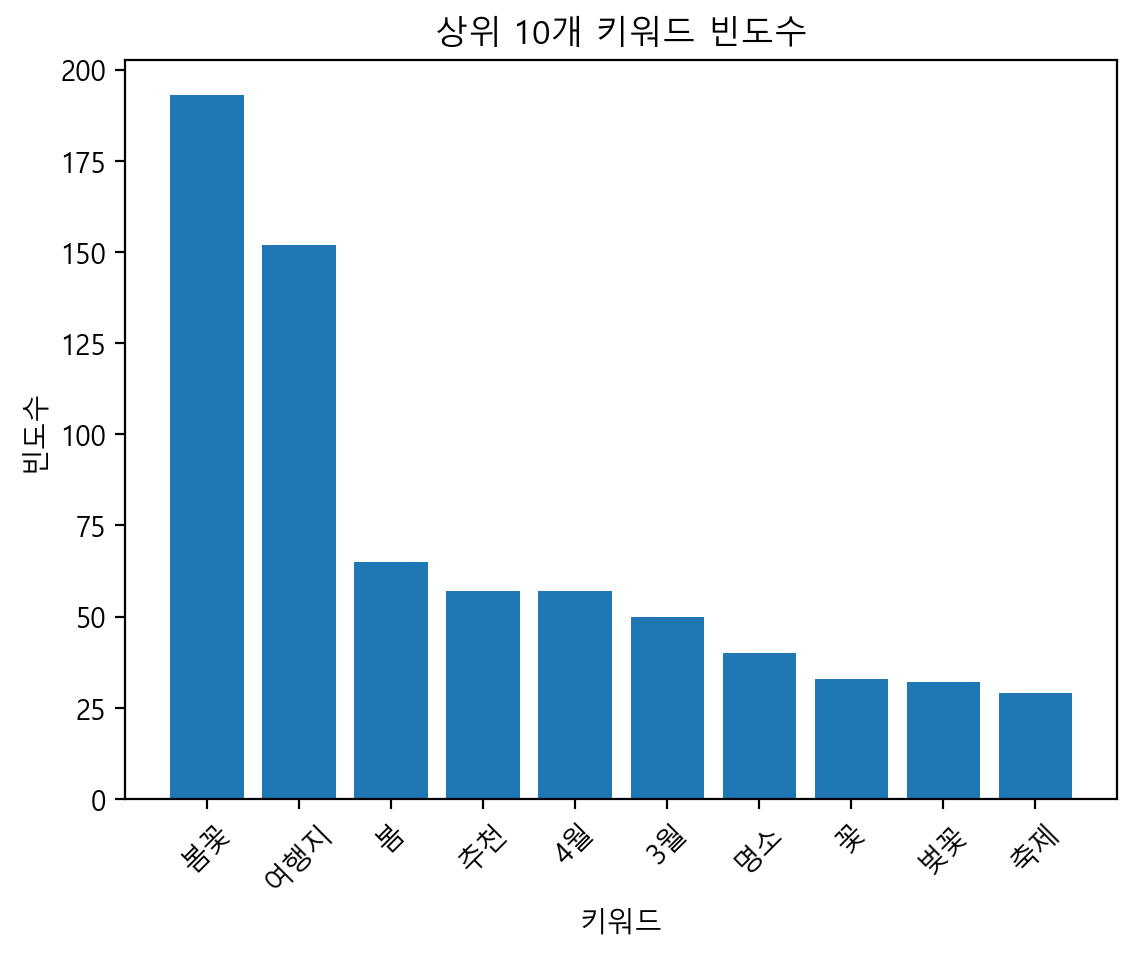

In [35]:
top_keywords = keywords.most_common(10)
words, counts = zip(*top_keywords)

plt.bar(words, counts)
plt.title("상위 10개 키워드 빈도수")
plt.xlabel("키워드")
plt.ylabel("빈도수")
plt.xticks(rotation=45)
plt.show()